# Image classification

Oskar Jonsson
20021113-8375

LLM Usage:

In [21]:
%pip install -q numpy matplotlib seaborn 
%pip install -q tensorflow keras
%pip install -q scikit-learn
%pip install -q pandas datetime


import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from datetime import datetime

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
def normalize_mnist():
    """
    Download MNIST dataset and normalize using min-max scaling to [0,1].
    """
    (x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
    
    print(f"MNIST - Train shape: {x_train.shape}, Test shape: {x_test.shape}")
    print(f"Original pixel range: [{x_train.min()}, {x_train.max()}]")
    
    # Min-max normalization to [0, 1]
    # Formula: (x - min) / (max - min)
    # For MNIST, min=0, max=255, so this simplifies to x/255.0
    x_train_normalized = x_train.astype('float32') / 255.0
    x_test_normalized = x_test.astype('float32') / 255.0
    
    print(f"Normalized pixel range: [{x_train_normalized.min():.2f}, {x_train_normalized.max():.2f}]")
    
    return (x_train_normalized, y_train), (x_test_normalized, y_test)
    
def normalize_cifar10():
    """
    Download CIFAR-10 dataset and normalize using Z-score normalization.
    """
    
    (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
    
    print(f"CIFAR-10 - Train shape: {x_train.shape}, Test shape: {x_test.shape}")
    print(f"Original pixel range: [{x_train.min()}, {x_train.max()}]")
    print(f"Original mean: {x_train.mean():.3f}, std: {x_train.std():.3f}")
    
    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')
    
    # Calculate mean and std from training data
    # For Z-score normalization: (x - mean) / std
    mean = x_train.mean()
    std = x_train.std()
    
    x_train_normalized = (x_train - mean) / std
    x_test_normalized = (x_test - mean) / std
    
    print(f"Train data - mean: {x_train_normalized.mean():.6f}, std: {x_train_normalized.std():.6f}")
    print(f"Test data - mean: {x_test_normalized.mean():.6f}, std: {x_test_normalized.std():.6f}")
    print(f"Train data - min: {x_train_normalized.min():.3f}, max: {x_train_normalized.max():.3f}")
    print(f"Test data - min: {x_test_normalized.min():.3f}, max: {x_test_normalized.max():.3f}")
    return (x_train_normalized, y_train), (x_test_normalized, y_test)

normalize_mnist()
normalize_cifar10()

MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093


((array([[[[-0.9619245 , -0.91515917, -0.8995707 ],
           [-1.2113398 , -1.1645745 , -1.1801629 ],
           [-1.1022207 , -1.1333976 , -1.2113398 ],
           ...,
           [ 0.58133286,  0.17603296, -0.19809005],
           [ 0.48780212,  0.06691375, -0.2916208 ],
           [ 0.4254483 ,  0.05132529, -0.27603233]],
  
          [[-1.6322283 , -1.5698744 , -1.5698744 ],
           [-1.8816435 , -1.8816435 , -1.8816435 ],
           [-1.6010513 , -1.756936  , -1.8816435 ],
           ...,
           [ 0.03573683, -0.5098592 , -1.0242784 ],
           [-0.026617  , -0.5878015 , -1.1022207 ],
           [ 0.02014837, -0.52544767, -0.9931014 ]],
  
          [[-1.4919322 , -1.5075206 , -1.554286  ],
           [-1.6322283 , -1.7725244 , -1.8816435 ],
           [-1.117809  , -1.4607552 , -1.756936  ],
           ...,
           [-0.04220546, -0.57221305, -1.1022207 ],
           [-0.01102854, -0.57221305, -1.1022207 ],
           [-0.18250158, -0.7436861 , -1.2269284 ]],
  
    

In [18]:
class MNIST_CNN:
    """
    CNN for MNIST.
    - Conv(16-64 filters) + BatchNorm + ReLU
    - MaxPool(2x2)
    - Conv(32-128 filters) + BatchNorm + ReLU
    - MaxPool(2x2)
    - Flatten + Dense(128) + ReLU + Dropout
    - Dense(10) + Softmax
    """
    
    def __init__(self, conv1_filters=32, conv2_filters=64, dropout_rate=0.3, learning_rate=0.001):
        """
        Initialize the CNN model.
        
        param: conv1_filters: Number of filters in first conv layer.
        param: conv2_filters: Number of filters in second conv layer.
        param: dropout_rate: Dropout rate for regularization.
        param: learning_rate: Learning rate for optimizer.
        """
        
        self.conv1_filters = conv1_filters
        self.conv2_filters = conv2_filters
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.model = None
        self.history = None
        
        self._build_model()
        
    
    def _build_model(self):
        """
        Build the CNN.
        """
        model = models.Sequential([
            # Input layer - MNIST images are 28x28x1
            layers.Input(shape=(28, 28, 1)),
            
            # First Convolutional Block
            layers.Conv2D(self.conv1_filters, (3, 3), 
                         padding='valid',  # No padding 
                         use_bias=False),  # Bias not needed with batch norm
            layers.BatchNormalization(),
            layers.ReLU(),
            
            # Max Pooling
            layers.MaxPooling2D((2, 2)),
            
            # Second Convolutional Block
            layers.Conv2D(self.conv2_filters, (3, 3),
                         padding='valid',
                         use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            
            # Max Pooling
            layers.MaxPooling2D((2, 2)),
            
            # Flatten for dense layers
            layers.Flatten(),
            
            # Dense layer with dropout
            layers.Dense(128, use_bias=True),
            layers.ReLU(),
            layers.Dropout(self.dropout_rate),
            
            # Output layer
            layers.Dense(10, activation='softmax')
        ])
        
        # Compile the model
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        self.model = model
        self.model.summary()
        
    def prepare_data(self, x_train, y_train, x_test, y_test, validation_split=0.1):
        """
        Prepare and preprocess the data.
        
        param: x_train: Training images.
        param: y_train: Training labels.
        param: x_test: Test images.
        param: y_test: Test labels.
        param: validation_split: Fraction of training data to use for validation.
        """
        # Ensure data is float32 and reshape if needed
        if len(x_train.shape) == 3:
            x_train = x_train.reshape(-1, 28, 28, 1)
            x_test = x_test.reshape(-1, 28, 28, 1)
        
        # Store data
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.validation_split = validation_split
        
        print(f"Training set: {x_train.shape}, {y_train.shape}")
        print(f"Test set: {x_test.shape}, {y_test.shape}")
        print(f"Validation split: {validation_split*100:.0f}%")
        
    def train(self, epochs=10, batch_size=32, verbose=1):
        """
        Train the model.
        
        param: epochs: Number of training epochs.
        param: batch_size: Batch size for training.
        param: verbose: Verbosity level for training output.
        """
        
        # Callbacks for better training
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=verbose
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=verbose
            )
        ]
        
        print(f"\nStarting training for {epochs} epochs")
        print(f"Batch size: {batch_size}")
        print(f"Dropout rate: {self.dropout_rate}")
        print(f"Learning rate: {self.learning_rate}")
        
        # Train the model
        self.history = self.model.fit(
            self.x_train, self.y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=self.validation_split,
            callbacks=callbacks_list,
            verbose=verbose
        )
        
        print("\nTraining complete")
        
        # Final evaluation
        train_loss, train_acc = self.model.evaluate(self.x_train, self.y_train, verbose=0)
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nFinal Results:")
        print(f"Training accuracy: {train_acc:.4f}")
        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Test loss: {test_loss:.4f}")
    
    def evaluate(self):
        """
        Evaluate the model and show detailed metrics.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Calculate metrics
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nTest Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Classification report
        print("\nClassification Report:")
        print("-" * 50)
        target_names = [str(i) for i in range(10)]
        print(classification_report(self.y_test, y_pred, target_names=target_names))
        
        return test_loss, test_acc, y_pred
    
    def plot_training_history(self):
        """
        Plot training history.
        """
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot accuracy
        axes[0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot loss
        axes[1].plot(self.history.history['loss'], label='Training Loss')
        axes[1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self):
        """
        Plot confusion matrix.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Compute confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        
        # Plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=range(10), yticklabels=range(10))
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
    
    def visualize_predictions(self, num_samples=10):
        """
        Visualize model predictions on test samples.
        """
        
        # Get random samples
        indices = np.random.choice(len(self.x_test), num_samples, replace=False)
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test[indices], verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Plot
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i, idx in enumerate(indices):
            axes[i].imshow(self.x_test[idx].reshape(28, 28), cmap='gray')
            axes[i].set_title(f'True: {self.y_test[idx]}, Pred: {y_pred[i]}')
            axes[i].axis('off')
            
            # Color code based on correct/incorrect prediction
            if self.y_test[idx] == y_pred[i]:
                axes[i].set_xlabel('Correct', color='green', fontsize=12)
            else:
                axes[i].set_xlabel('Incorrect', color='red', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath='mnist_cnn_model.keras'):
        """
        Save the trained model.
        """
        
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath='mnist_cnn_model.keras'):
        """
        Load a saved model.
        """
        
        self.model = models.load_model(filepath)
        print(f"Model loaded from {filepath}")
        self.model.summary()





CNN

1. Loading MNIST dataset...
MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)

2. Creating CNN model


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,322 (880.16 KB)

 Trainable params: 225,130 (879.41 KB)

 Non-trainable params: 192 (768.00 B)


3. Preparing data...
Training set: (60000, 28, 28, 1), (60000,)
Test set: (10000, 28, 28, 1), (10000,)
Validation split: 10%

4. Training model...

Starting training for 15 epochs
Batch size: 128
Dropout rate: 0.3
Learning rate: 0.001
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9329 - loss: 0.2194 - val_accuracy: 0.8767 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9779 - loss: 0.0723 - val_accuracy: 0.9860 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9823 - loss: 0.0583 - val_accuracy: 0.9897 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9882 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9915 - val_loss: 0.0332 - learning_rate: 0

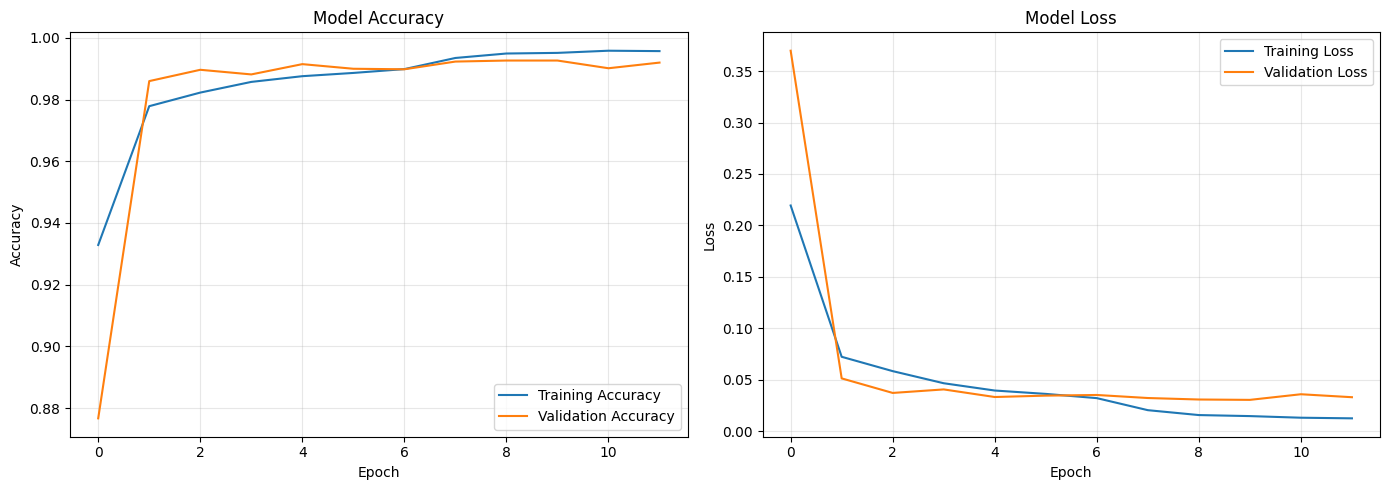


7. Plotting confusion matrix...


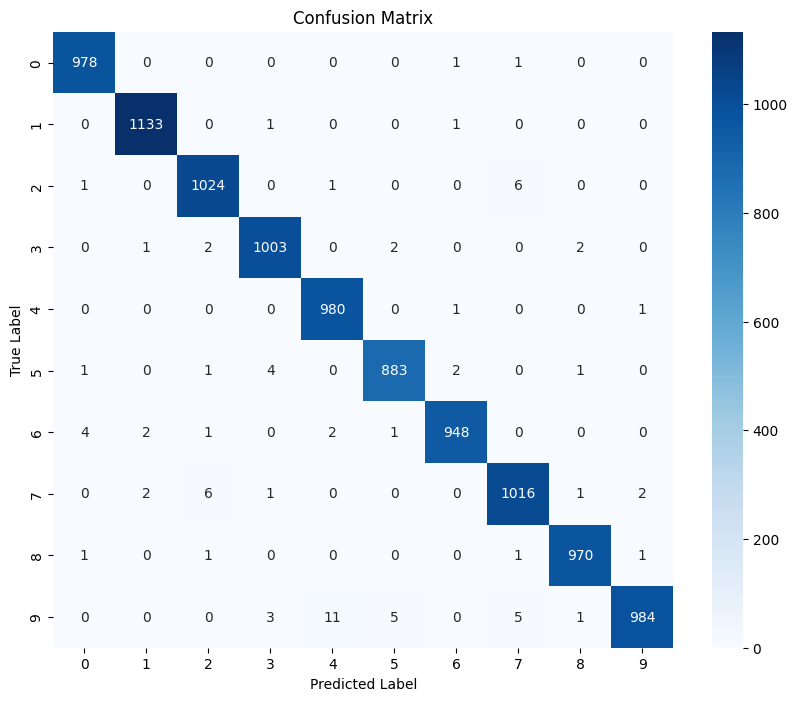


8. Visualizing sample predictions...


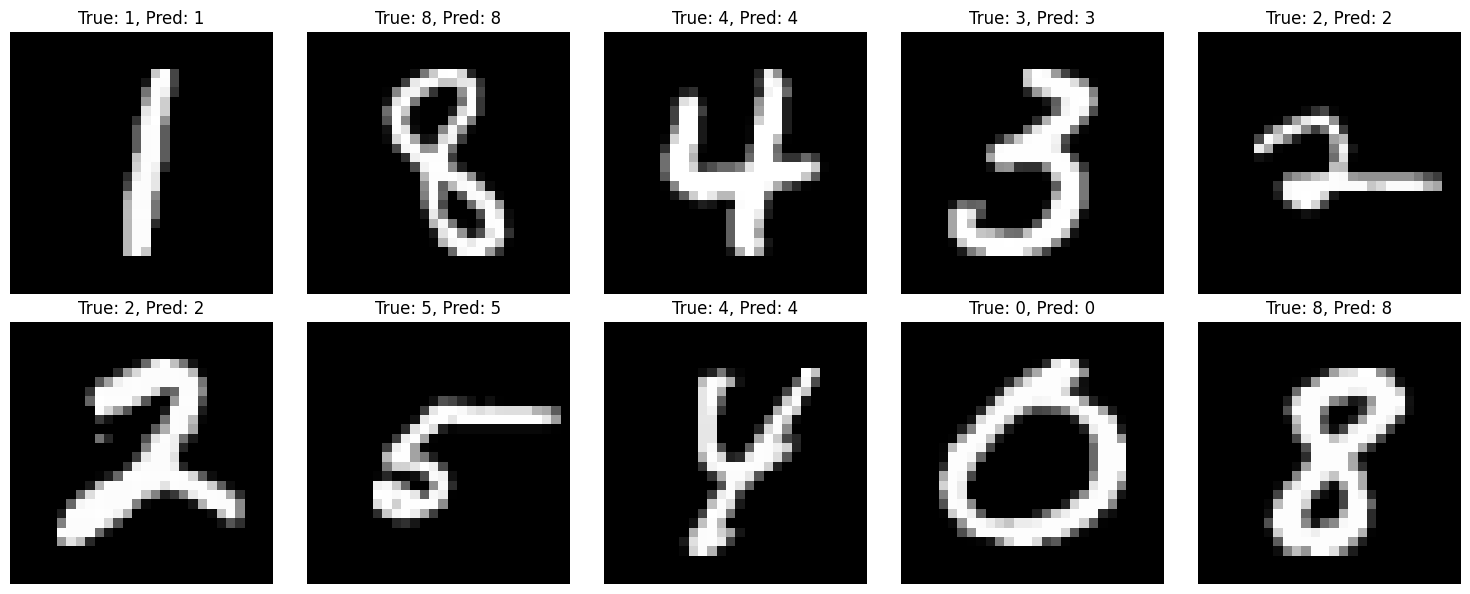


9. Saving model...
Model saved to mnist_cnn_model.keras


In [20]:
def main():
    """
    Main function to demonstrate the CNN class
    """

    print("\nCNN")
    # Load and normalize MNIST data
    print("\n1. Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = normalize_mnist()
    
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    
    # Create CNN instance 
    print("\n2. Creating CNN model")
    cnn = MNIST_CNN(
        conv1_filters=32,    # Within [16,64]
        conv2_filters=64,     # Within [32,128]
        dropout_rate=0.3,     # Within [0.2,0.5]
        learning_rate=0.001
    )
    
    # Prepare data
    print("\n3. Preparing data...")
    cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
    
    # Train the model
    print("\n4. Training model...")
    cnn.train(epochs=15, batch_size=128, verbose=1)
    
    # Evaluate
    print("\n5. Evaluating model...")
    cnn.evaluate()
    
    # Plot training history
    print("\n6. Plotting training history...")
    cnn.plot_training_history()
    
    # Plot confusion matrix
    print("\n7. Plotting confusion matrix...")
    cnn.plot_confusion_matrix()
    
    # Visualize predictions
    print("\n8. Visualizing sample predictions...")
    cnn.visualize_predictions(10)
    
    # Save model
    print("\n9. Saving model...")
    cnn.save_model('mnist_cnn_model.keras')
    

if __name__ == "__main__":
    main()

In [24]:
class CIFAR10_CNN:
    """
    CNN for CIFAR-10 classification.
    CIFAR-10 images are 32x32x3 (color images)
    - Multiple conv layers with padding (border pixels matter)
    - Batch Normalization
    - Max Pooling
    - Dropout for regularization
    - Dense layers with softmax output
    """
    
    def __init__(self, 
                 architecture_type='default',  # 'default', 'vgg', 'nin', 'residual', 'inception'
                 conv1_filters=32,      
                 conv2_filters=64,       
                 conv3_filters=128,      
                 conv4_filters=256,      
                 dense_units=512,        
                 dropout_rate=0.3,       
                 learning_rate=0.001,
                 experiment_name=None):
        """
        Initialize the CNN model.
        
        param: architecture_type: Type of architecture to build.
        param: conv1_filters: Number of filters in first conv layer.
        param: conv2_filters: Number of filters in second conv layer.
        param: conv3_filters: Number of filters in third conv layer.
        param: conv4_filters: Number of filters in fourth conv layer.
        param: dense_units: Number of units in dense layer.
        param: dropout_rate: Dropout rate for regularization.
        param: learning_rate: Learning rate for optimizer.
        param: experiment_name: Name for this experiment.
        """
        
        self.architecture_type = architecture_type
        self.conv1_filters = conv1_filters
        self.conv2_filters = conv2_filters
        self.conv3_filters = conv3_filters
        self.conv4_filters = conv4_filters
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.experiment_name = experiment_name or f"cifar10_{architecture_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.model = None
        self.history = None
        self.test_accuracy = None
        
        self._build_model()
        
    def _build_model(self):
        """
        Build the CNN architecture based on selected type.
        """
        
        if self.architecture_type == 'default':
            model = self._build_default_architecture()
        elif self.architecture_type == 'vgg':
            model = self._build_vgg_style()
        elif self.architecture_type == 'nin':
            model = self._build_nin_style()
        elif self.architecture_type == 'residual':
            model = self._build_residual_style()
        elif self.architecture_type == 'inception':
            model = self._build_inception_style()
        elif self.architecture_type == 'wide':
            model = self._build_wide_architecture()
        elif self.architecture_type == 'deep':
            model = self._build_deep_architecture()
        else:
            print(f"Unknown architecture type '{self.architecture_type}'. Using default.")
            model = self._build_default_architecture()
        
        # Compile the model
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        self.model = model
        print(f"\n{'='*60}")
        print(f"Architecture Type: {self.architecture_type.upper()}")
        print(f"Experiment: {self.experiment_name}")
        print(f"{'='*60}")
        self.model.summary()
    
    def _build_default_architecture(self):
        """
        Default architecture - 4 conv blocks.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # First Convolutional Block
            layers.Conv2D(self.conv1_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv1_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.2),
            
            # Second Convolutional Block
            layers.Conv2D(self.conv2_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv2_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Third Convolutional Block
            layers.Conv2D(self.conv3_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv3_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            # Fourth Convolutional Block
            layers.Conv2D(self.conv4_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            
            # Dense layers
            layers.Dense(self.dense_units, use_bias=True),
            layers.ReLU(),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            
            layers.Dense(self.dense_units // 2, use_bias=True),
            layers.ReLU(),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_vgg_style(self):
        """
        VGG-style architecture - multiple convolutions before pooling.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1: 2x conv
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Block 2: 2x conv
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            # Block 3: 3x conv (deeper)
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.5),
            
            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_nin_style(self):
        """
        Network in Network (NiN) style - using 1x1 convolutions.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1
            layers.Conv2D(192, (5, 5), padding='same', activation='relu'),
            layers.Conv2D(160, (1, 1), padding='same', activation='relu'),  # 1x1 conv
            layers.Conv2D(96, (1, 1), padding='same', activation='relu'),   # 1x1 conv
            layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
            layers.Dropout(0.3),
            
            # Block 2
            layers.Conv2D(192, (5, 5), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
            layers.Dropout(0.4),
            
            # Block 3
            layers.Conv2D(192, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.Conv2D(10, (1, 1), padding='same', activation='relu'),   # Reduce to 10 channels
            
            # Global Average Pooling (instead of Flatten)
            layers.GlobalAveragePooling2D(),
            layers.Activation('softmax')
        ])
        return model
    
    def _build_residual_style(self):
        """
        Residual network style with skip connections.
        """
        inputs = layers.Input(shape=(32, 32, 3))
        
        # Initial convolution
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        
        # Residual Block 1 (no dimension change)
        shortcut = x
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (32, 32, 32)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (16, 16, 32)
        x = layers.Dropout(0.2)(x)
        
        # Residual Block 2 (with dimension change via pooling)
        shortcut = x  # (16, 16, 32)
        x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (16, 16, 64) after conv
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (8, 8, 64)
        x = layers.Dropout(0.3)(x)
        
        # Residual Block 3 (with dimension change via pooling)
        shortcut = x  # (8, 8, 64)
        x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (8, 8, 128)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (4, 4, 128)
        x = layers.Dropout(0.4)(x)
        
        # Output
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(10, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        return model
    
    def _build_inception_style(self):
        """
        Inception-style with multiple parallel convolutions.
        """
        inputs = layers.Input(shape=(32, 32, 3))
        
        # Inception Block 1
        tower_1 = layers.Conv2D(32, (1, 1), padding='same', activation='relu')(inputs)
        tower_1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(tower_1)
        
        tower_2 = layers.Conv2D(32, (1, 1), padding='same', activation='relu')(inputs)
        tower_2 = layers.Conv2D(64, (5, 5), padding='same', activation='relu')(tower_2)
        
        tower_3 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(inputs)
        tower_3 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(tower_3)
        
        x = layers.Concatenate()([tower_1, tower_2, tower_3])
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)
        
        # Inception Block 2
        tower_1 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
        tower_1 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(tower_1)
        
        tower_2 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
        tower_2 = layers.Conv2D(128, (5, 5), padding='same', activation='relu')(tower_2)
        
        tower_3 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
        tower_3 = layers.Conv2D(128, (1, 1), padding='same', activation='relu')(tower_3)
        
        x = layers.Concatenate()([tower_1, tower_2, tower_3])
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.4)(x)
        
        # Output
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(10, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        return model
    
    def _build_wide_architecture(self):
        """
        Wide architecture - fewer layers but more filters per layer.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Wide blocks with many filters
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            layers.Conv2D(512, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            
            layers.Dense(1024, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_deep_architecture(self):
        """
        Deep architecture - many layers but moderate filters.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1
            layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.1),
            
            # Block 2
            layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.2),
            
            # Block 3
            layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.2),
            
            # Block 4
            layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Block 5
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.3),
            
            # Block 6
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.3),
            
            # Block 7
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def prepare_data(self, x_train, y_train, x_test, y_test, validation_split=0.1):
        """
        Prepare and preprocess the data.
        
        param: x_train: Training images.
        param: y_train: Training labels.
        param: x_test: Test images.
        param: y_test: Test labels.
        param: validation_split: Fraction of training data to use for validation.
        """
        # Ensure data is float32 and reshape if needed
        if len(x_train.shape) == 3:
            x_train = x_train.reshape(-1, 32, 32, 3)
            x_test = x_test.reshape(-1, 32, 32, 3)
        
        # Store data
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.validation_split = validation_split
        
        print(f"\nData prepared:")
        print(f"Training set: {x_train.shape}, {y_train.shape}")
        print(f"Test set: {x_test.shape}, {y_test.shape}")
        print(f"Validation split: {validation_split*100:.0f}%")
        
    def train(self, epochs=50, batch_size=64, verbose=1):
        """
        Train the model.
        
        param: epochs: Number of training epochs.
        param: batch_size: Batch size for training.
        param: verbose: Verbosity level for training output.
        """
        
        # Callbacks for better training
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=verbose
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=verbose
            ),
            callbacks.ModelCheckpoint(
                filepath=f'best_{self.experiment_name}.keras',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=verbose
            )
        ]
        
        print(f"\nStarting training for {epochs} epochs")
        print(f"Batch size: {batch_size}")
        print(f"Dropout rate: {self.dropout_rate}")
        print(f"Learning rate: {self.learning_rate}")
        print("-" * 50)
        
        # Train the model
        self.history = self.model.fit(
            self.x_train, self.y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=self.validation_split,
            callbacks=callbacks_list,
            verbose=verbose
        )
        
        print("\nTraining complete")
        
        # Final evaluation
        train_loss, train_acc = self.model.evaluate(self.x_train, self.y_train, verbose=0)
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        self.test_accuracy = test_acc
        
        print(f"\nFinal Results:")
        print(f"Training accuracy: {train_acc:.4f}")
        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Test loss: {test_loss:.4f}")
        
        return test_acc
    
    def evaluate(self):
        """
        Evaluate the model and show detailed metrics.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Calculate metrics
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nTest Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Classification report
        print("\nClassification Report:")
        print("-" * 50)
        target_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']
        print(classification_report(self.y_test, y_pred, target_names=target_names))
        
        return test_loss, test_acc, y_pred
    
    def plot_training_history(self):
        """
        Plot training history.
        """
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot accuracy
        axes[0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title(f'Model Accuracy - {self.architecture_type}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot loss
        axes[1].plot(self.history.history['loss'], label='Training Loss')
        axes[1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[1].set_title(f'Model Loss - {self.architecture_type}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self):
        """
        Plot confusion matrix.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Compute confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        
        # Plot
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['airplane', 'automobile', 'bird', 'cat', 'deer',
                               'dog', 'frog', 'horse', 'ship', 'truck'],
                    yticklabels=['airplane', 'automobile', 'bird', 'cat', 'deer',
                               'dog', 'frog', 'horse', 'ship', 'truck'])
        plt.title(f'Confusion Matrix - {self.architecture_type}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def visualize_predictions(self, num_samples=10):
        """
        Visualize model predictions on test samples.
        """
        
        # Get random samples
        indices = np.random.choice(len(self.x_test), num_samples, replace=False)
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test[indices], verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Class names
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                      'dog', 'frog', 'horse', 'ship', 'truck']
        
        # Plot
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i, idx in enumerate(indices):
            # Denormalize for visualization 
            img = self.x_test[idx].copy()
            # Simple clipping to [0,1] range for display
            img = np.clip(img, 0, 1)
            
            axes[i].imshow(img)
            true_label = class_names[self.y_test[idx][0]] if hasattr(self.y_test[idx], '__len__') else class_names[self.y_test[idx]]
            pred_label = class_names[y_pred[i]]
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
            axes[i].axis('off')
            
            # Color code based on correct/incorrect prediction
            true_val = self.y_test[idx][0] if hasattr(self.y_test[idx], '__len__') else self.y_test[idx]
            if true_val == y_pred[i]:
                axes[i].set_xlabel('Correct', color='green', fontsize=12)
            else:
                axes[i].set_xlabel('Incorrect', color='red', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath=None):
        """
        Save the trained model.
        """
        if filepath is None:
            filepath = f'{self.experiment_name}.keras'
        
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath):
        """
        Load a saved model.
        """
        self.model = models.load_model(filepath)
        print(f"Model loaded from {filepath}")
        self.model.summary()


# Experiment runner to find best architecture
def run_architecture_experiments(x_train, y_train, x_test, y_test, epochs=30):
    """
    Run experiments with different architectures and find the best one.
    """
    
    architectures = [
        #'default',
        #'vgg',
        #'nin',
        'residual',
        'inception',
        'wide',
        'deep'
    ]
    
    results = []
    
    print("RUNNING ARCHITECTURE EXPERIMENTS")
    
    for arch in architectures:
        print(f"\nTesting Architecture: {arch.upper()}")
        
        # Create model with current architecture
        cnn = CIFAR10_CNN(
            architecture_type=arch,
            conv1_filters=32,
            conv2_filters=64,
            conv3_filters=128,
            conv4_filters=256,
            dense_units=512,
            dropout_rate=0.3,
            learning_rate=0.001,
            experiment_name=f"cifar10_{arch}"
        )
        
        # Prepare data
        cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
        
        # Train model
        test_acc = cnn.train(epochs=epochs, batch_size=64, verbose=1)
        
        # Store results
        results.append({
            'architecture': arch,
            'test_accuracy': test_acc,
            'experiment_name': cnn.experiment_name
        })
        
        # Save model
        cnn.save_model()
        
        print(f"\n{arch.upper()} completed with test accuracy: {test_acc:.4f}")
    
    # Find best architecture
    results_df = pd.DataFrame(results)
    best_result = results_df.loc[results_df['test_accuracy'].idxmax()]
    
    print("EXPERIMENT RESULTS SUMMARY")
    print(results_df.to_string(index=False))
    
    print(f"BEST ARCHITECTURE: {best_result['architecture'].upper()}")
    print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
    print(f"Experiment: {best_result['experiment_name']}")
    
    return results_df, best_result


In [25]:
def main():
    """
    Main function to demonstrate the CIFAR-10 CNN class with experiments.
    """
    print("CIFAR-10 CNN ARCHITECTURE EXPERIMENTS")
    
    # Load normalized CIFAR-10 data
    print("\n1. Loading CIFAR-10 dataset...")
    (x_train, y_train), (x_test, y_test) = normalize_cifar10()
    
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    
    # Run experiments with different architectures
    results_df, best_result = run_architecture_experiments(
        x_train, y_train, x_test, y_test, 
        epochs=30  
    )
    
    # Train the best architecture longer for final model
    print(f"TRAINING BEST ARCHITECTURE ({best_result['architecture'].upper()}) FOR FINAL MODEL")
    
    best_cnn = CIFAR10_CNN(
        architecture_type=best_result['architecture'],
        conv1_filters=32,
        conv2_filters=64,
        conv3_filters=128,
        conv4_filters=256,
        dense_units=512,
        dropout_rate=0.3,
        learning_rate=0.001,
        experiment_name=f"best_cifar10_{best_result['architecture']}_final"
    )
    
    best_cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
    best_cnn.train(epochs=50, batch_size=64, verbose=1)
    
    # Final evaluation
    print("FINAL MODEL EVALUATION")
    best_cnn.evaluate()
    
    # Plot results
    best_cnn.plot_training_history()
    best_cnn.plot_confusion_matrix()
    best_cnn.visualize_predictions(10)
    
    # Save final model
    best_cnn.save_model('best_cifar10_model.keras')
    
    return best_cnn, results_df


if __name__ == "__main__":
    best_model, results = main()

CIFAR-10 CNN ARCHITECTURE EXPERIMENTS

1. Loading CIFAR-10 dataset...
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
RUNNING ARCHITECTURE EXPERIMENTS

Testing Architecture: RESIDUAL


ValueError: Inputs have incompatible shapes. Received shapes (16, 16, 64) and (16, 16, 32)

For the CIFAR10 set we use 7 different architecture types and tests which one performs best. 

Default is a 4 blocks design that uses 2 convolutional layers per block. For each block the filters increase and dropout increases. Global average pool at the end.

VGG uses stacked convolutions before pooling with consistant filter size throughout the block. Deeper in later blocks and uses Flatten() instead of global pooling. Slower as we train more parameters.

NIN uses 1x1 convolutions as small netowkrs. Each 1x1 convolutes each regular convolution and ends with gloabal average pooling. Fewer parameters so faster but is harder to train as underfitting might occurs with smaller datasets.

ResNet skips connections and solves vanishing gradient. Projects shortcuts when dimensions change and can therefore train very deep.

Inception uses multiple parallel convolution paths (1x1, 3x3, 5x5) and uses outputs from different scales. 1x1 reducees dimensionality. Captures features at multiple spatial scales and pools each path in parallel.

Wide uses fewer layers but wider filters. More parameters per layer might cause overfitting but is also able to capture more features per layer.

Deep uses many layers with gradual increase. Heavy dropout throughout with moderate filter sizes.

Again validation split of 10\% of training data.